# Institutional Holdings Graph: Point-in-Time 13F Features

**Docker image**: `ml4t`

**Chapter 22: RAG for Financial Research** (Section 22.8)

This notebook constructs a bipartite institution-stock graph from 13F
holdings and derives co-ownership similarity, crowding, and institutional
ownership-change descriptors for downstream research.

**Learning Objectives**:
- Build a normalized institution-by-stock ownership matrix and translate it
  into stock-stock cosine similarity
- Engineer cross-sectional ownership-breadth and ownership-change features
- Identify portfolio overlap and strategy clusters via institution-institution
  similarity
- Inspect the stock-level features that downstream GNN pipelines consume
  (the canonical downloader is the producer; Chapter 23 is the consumer)

**Book Reference**: Chapter 22, Section 22.8 (Applications)

**Prerequisites**: The raw 13F holdings are produced by the canonical
downloader at `data/equities/positioning/13f_download.py`; run it once
before this notebook (or see `data/equities/fundamentals/README.md`).
The download mechanics (SEC EDGAR submissions API, XML information tables)
are covered in Chapter 4, NB 05.

## What 13F Data Exposes

- **Delayed disclosure**: reporting-quarter positions become observable only
  on their SEC filing dates
- **Manager-level positions**: Quarter-end long equity holdings by reporting
  institution, joinable to price data for downstream feature studies
- **Crowding descriptors**: Breadth and concentration summarize how disclosed
  ownership is distributed; liquidation pressure is not measured here
- **Co-ownership structure**: Stocks sharing institutional holders form a
  bipartite graph usable for similarity and clustering analysis

## 1. Setup and Imports

These parameters control the institution universe and filing horizon the
downstream analysis uses. The raw data is already on disk - this notebook
loads it via the canonical loader and filters it for the graph experiments.

In [1]:
"""Institutional Holdings Graph - point-in-time 13F ownership descriptors."""

import warnings

from IPython.display import display

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
from polars.testing import assert_frame_equal

from data import load_13f_edges, load_13f_stock_features, load_institutional_holdings_13f
from utils.style import COLORS

In [2]:
NUM_QUARTERS = 4
MAX_INSTITUTIONS = 0

# Institution universe (name, CIK with leading-zero padding). Rows for any
# other CIKs present in the artifact are filtered out. Extend this list to
# widen the analysis.
ALL_INSTITUTIONS = [
    ("Berkshire Hathaway", "0001067983"),
    ("Bridgewater Associates", "0001350694"),
    ("Renaissance Technologies", "0001037389"),
    ("Two Sigma Investments", "0001450144"),
    ("DE Shaw", "0001009207"),
    ("AQR Capital", "0001167557"),
    ("Citadel Advisors", "0001423053"),
    ("Millennium Management", "0001273087"),
    ("Point72 Asset Management", "0001603466"),
    ("Tiger Global", "0001167483"),
]

In [3]:
INSTITUTIONS = (
    ALL_INSTITUTIONS[:MAX_INSTITUTIONS] if MAX_INSTITUTIONS > 0 else ALL_INSTITUTIONS.copy()
)
SELECTED_CIKS = [cik for _, cik in INSTITUTIONS]
INSTITUTION_NAMES = {cik: name for name, cik in INSTITUTIONS}

print(f"Institution filter: {len(INSTITUTIONS)}")
print(f"Quarters to retain: {NUM_QUARTERS}")

Institution filter: 10
Quarters to retain: 4


## Part 1: Load Holdings Data

`data/equities/positioning/13f_download.py` fetches 13F-HR filings from SEC
EDGAR, parses each information table, and writes a single
`institutional_holdings.parquet` artifact to
`$ML4T_DATA_PATH/equities/positioning/13f/`. We read that artifact
directly and narrow it to the institutions and quarters of interest.

If the file is missing, the loader raises `DataNotFoundError` with a pointer
to the downloader and its README.

**Interpretation**: The institution count and quarter window determine the
graph density. That result directly affects the crowding, similarity, and
ownership-change descriptors later in the notebook.

In [4]:
holdings_df = load_institutional_holdings_13f()
required_provenance = {"report_date", "put_call"}
missing_provenance = required_provenance - set(holdings_df.columns)
if missing_provenance:
    raise ValueError(
        "The canonical 13F artifact lacks required SEC provenance: "
        f"{sorted(missing_provenance)}. Regenerate it with the canonical downloader."
    )
if holdings_df.schema["report_date"] != pl.Date:
    raise TypeError("Canonical 13F report_date must use the Polars Date type.")

# Filter to the CIKs listed in ALL_INSTITUTIONS. The artifact may contain a
# wider or narrower set; rows outside this universe are dropped.
holdings_df = holdings_df.filter(pl.col("cik").is_in(SELECTED_CIKS))
option_rows = holdings_df.filter(
    pl.col("put_call").fill_null("").cast(pl.Utf8).str.strip_chars() != ""
).height
holdings_df = holdings_df.filter(
    pl.col("put_call").fill_null("").cast(pl.Utf8).str.strip_chars() == ""
)
print(f"Excluded {option_rows:,} put/call rows; retained long-equity rows only.")

if holdings_df["filing_date"].min().isoformat() < "2023-01-03":
    raise ValueError("Pre-2023 13F values require a thousands-to-dollars conversion.")

# The producer retains its legacy `value_thousands` field name, but SEC filings
# after 2023-01-03 report market value in dollars. SEC reportDate supplies the
# authoritative quarter identity; filing date remains the availability time.
holdings_df = holdings_df.with_columns(
    pl.col("value_thousands").cast(pl.Float64).alias("reported_value_usd"),
    pl.col("report_date").alias("report_period"),
)

Excluded 47,181 put/call rows; retained long-equity rows only.


In [5]:
# A reporting quarter becomes available only after the last included manager
# files. Duplicate CIK/CUSIP rows in an information table are summed rather than
# selected positionally.
quarter_availability = holdings_df.group_by("report_period").agg(
    pl.col("filing_date").max().alias("timestamp")
)

Canonicalize each CUSIP's issuer label by the largest disclosed value in that
reporting period, with a lexical tie-break. This keeps graph labels stable.

In [6]:
issuer_names = (
    holdings_df.group_by(["cusip", "report_period", "issuer"])
    .agg(pl.col("reported_value_usd").sum().alias("issuer_value_usd"))
    .sort(
        ["cusip", "report_period", "issuer_value_usd", "issuer"],
        descending=[False, False, True, False],
    )
    .unique(subset=["cusip", "report_period"], keep="first", maintain_order=True)
    .select("cusip", "report_period", pl.col("issuer").alias("issuer"))
)
positions_df = (
    holdings_df.group_by(["cik", "cusip", "report_period"])
    .agg(
        pl.col("company_name").sort().first().alias("company_name"),
        pl.col("reported_value_usd").sum().alias("reported_value_usd"),
        pl.col("shares").sum().alias("shares"),
    )
    .filter(pl.col("reported_value_usd") > 0)
    .join(issuer_names, on=["cusip", "report_period"], how="left")
    .join(quarter_availability, on="report_period", how="left")
)

if NUM_QUARTERS > 0:
    recent_periods = (
        positions_df["report_period"].unique().sort(descending=True).head(NUM_QUARTERS).to_list()
    )
    positions_df = positions_df.filter(pl.col("report_period").is_in(recent_periods))

assert (
    positions_df.select(pl.struct(["cik", "cusip", "report_period"]).is_duplicated().any()).item()
    is False
)

print(
    f"\nTotal: {len(positions_df):,} aggregated positions across "
    f"{positions_df['report_period'].n_unique()} reporting quarters and "
    f"{positions_df['cik'].n_unique()} institutions"
)


Total: 95,845 aggregated positions across 4 reporting quarters and 10 institutions


**Interpretation**: The filtered panel exposes the core constraints of 13F
data: sparse quarterly snapshots, filing lags, and heterogeneous institution
coverage. The notebook therefore treats each row as a disclosed quarter-end
position, not as evidence about holdings between reports.

## Part 2: Bipartite Graph Construction

The fundamental structure is an **Institution -> Stock** edge list with value
and share weights that can be reused for graph analytics and feature export.

In [7]:
# Get most recent snapshot per institution-stock pair
if len(positions_df) > 0:
    latest_period = positions_df["report_period"].max()
    latest_holdings = positions_df.filter(pl.col("report_period") == latest_period)

    n_inst = latest_holdings["cik"].n_unique()
    n_stocks = latest_holdings["cusip"].n_unique()
    n_edges = len(latest_holdings)

    print("=== Bipartite Graph Structure ===")
    print(f"Institution nodes: {n_inst}")
    print(f"Stock nodes: {n_stocks}")
    print(f"Edges (holdings): {n_edges:,}")
    print(f"Density: {n_edges / (n_inst * n_stocks):.4f}")
    print(f"Avg holdings per institution: {n_edges / n_inst:.0f}")
    print(f"Avg institutions per stock: {n_edges / n_stocks:.2f}")
else:
    latest_holdings = positions_df

=== Bipartite Graph Structure ===
Institution nodes: 10
Stock nodes: 7998
Edges (holdings): 24,672
Density: 0.3085
Avg holdings per institution: 2467
Avg institutions per stock: 3.08


## Part 3: Co-Ownership Analysis

**Key insight**: Common disclosed owners create a stock-stock similarity graph useful for:
- Portfolio diversification (avoid co-owned stocks)
- Factor construction (co-ownership as a factor)
- Risk management (crowding detection)

**Interpretation**: The bipartite summary print translates raw filings into a
network object. That result is the bridge from disclosure data to tradable
signals such as overlap, concentration, and shared ownership pressure.

In [8]:
def build_ownership_matrix(holdings: pl.DataFrame) -> tuple[np.ndarray, list[str]]:
    """Build an institution-by-stock matrix weighted by reported position value."""
    stocks = sorted(holdings["cusip"].unique().to_list())
    institutions = sorted(holdings["cik"].unique().to_list())
    stock_idx = {s: i for i, s in enumerate(stocks)}
    inst_idx = {c: i for i, c in enumerate(institutions)}

    ownership = np.zeros((len(institutions), len(stocks)), dtype=np.float32)
    for row in holdings.iter_rows(named=True):
        ownership[inst_idx[row["cik"]], stock_idx[row["cusip"]]] = row["reported_value_usd"]

    row_sums = ownership.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return ownership / row_sums, stocks

### Stock co-ownership similarity

Convert the normalized institution-by-stock matrix into a stock-by-stock
cosine-similarity matrix for crowding and overlap analysis.


In [9]:
def compute_coownership_matrix(holdings: pl.DataFrame) -> tuple[np.ndarray, list[str]]:
    """Compute the stock-level co-ownership similarity matrix."""
    ownership_norm, stocks = build_ownership_matrix(holdings)
    coown = ownership_norm.T @ ownership_norm
    diag = np.sqrt(np.diag(coown))
    diag[diag == 0] = 1
    similarity = coown / np.outer(diag, diag)
    return similarity, stocks

In [10]:
if len(latest_holdings) > 0:
    coown_matrix, stock_list = compute_coownership_matrix(latest_holdings)

    print("=== Co-Ownership Matrix ===")
    print(f"Shape: {coown_matrix.shape}")
    print(f"Sparsity: {(coown_matrix < 0.01).mean():.1%} of pairs have <1% similarity")

    # Find stocks with highest co-ownership
    np.fill_diagonal(coown_matrix, 0)  # Ignore self-similarity
    row_idx, col_idx = np.triu_indices_from(coown_matrix, k=1)
    pair_values = coown_matrix[row_idx, col_idx]
    max_similarity = float(pair_values.max()) if len(pair_values) else 0.0

    if max_similarity > 0:
        tied = np.flatnonzero(np.isclose(pair_values, max_similarity, rtol=1e-7, atol=1e-8))
        selected = min(
            tied,
            key=lambda index: (
                stock_list[row_idx[index]],
                stock_list[col_idx[index]],
            ),
        )
        stock_a = stock_list[row_idx[selected]]
        stock_b = stock_list[col_idx[selected]]
        similarity = pair_values[selected]

        # Get issuer names
        name_a = latest_holdings.filter(pl.col("cusip") == stock_a)["issuer"].first()
        name_b = latest_holdings.filter(pl.col("cusip") == stock_b)["issuer"].first()

        print("\nHighest co-ownership pair:")
        print(f"  {name_a} ({stock_a})")
        print(f"  {name_b} ({stock_b})")
        print(f"  Similarity: {similarity:.3f}")

=== Co-Ownership Matrix ===
Shape: (7998, 7998)
Sparsity: 27.8% of pairs have <1% similarity



Highest co-ownership pair:
  THE BEACHBODY COMPANY INC (073463309)
  CURIS INC (231269309)
  Similarity: 1.000


**Interpretation**: The highest-similarity pair identifies securities with the
most similar disclosed owner weights. It does not measure return comovement.

## Part 4: Institutional Ownership Change

**Construction**: Aggregate change in institutional ownership across quarters.
This notebook measures the construction; whether the resulting feature carries
forward-return predictive content is an empirical question that downstream
Chapter 11/12 pipelines evaluate against price data, not a claim made here.

### Select comparable quarter snapshots

Rename period-specific fields before joining the latest two reporting periods.

In [11]:
def select_stock_quarter(df: pl.DataFrame, period, suffix: str) -> pl.DataFrame:
    return df.filter(pl.col("report_period") == period).select(
        "cusip",
        pl.col("issuer_name").alias(f"issuer_{suffix}"),
        pl.col("quarter_value_usd").alias(f"value_{suffix}_usd"),
        pl.col("n_institutions").alias(f"n_institutions_{suffix}"),
    )

In [12]:
if len(positions_df) > 0 and positions_df["report_period"].n_unique() > 1:
    stock_quarter = positions_df.group_by(["cusip", "report_period"]).agg(
        pl.col("issuer").first().alias("issuer_name"),
        pl.col("reported_value_usd").sum().alias("quarter_value_usd"),
        pl.col("cik").n_unique().alias("n_institutions"),
        pl.col("timestamp").max().alias("timestamp"),
    )
    comparison_periods = stock_quarter["report_period"].unique().sort(descending=True).head(2)
    current_period, prior_period = comparison_periods.to_list()
    current_availability = positions_df.filter(pl.col("report_period") == current_period)[
        "timestamp"
    ].max()
    prior = select_stock_quarter(stock_quarter, prior_period, "q1")
    current = select_stock_quarter(stock_quarter, current_period, "q2")
    qoq = (
        prior.join(current, on="cusip", how="full", coalesce=True)
        .with_columns(
            pl.coalesce("issuer_q2", "issuer_q1").alias("issuer_name"),
            pl.lit(current_availability).alias("timestamp"),
            pl.col("value_q1_usd").fill_null(0),
            pl.col("value_q2_usd").fill_null(0),
            pl.col("n_institutions_q1").fill_null(0),
            pl.col("n_institutions_q2").fill_null(0),
        )
        .with_columns(
            (pl.col("value_q2_usd") - pl.col("value_q1_usd")).alias("value_change_usd"),
            pl.max_horizontal("n_institutions_q1", "n_institutions_q2").alias("n_institutions"),
            pl.when(pl.col("value_q1_usd") > 0)
            .then((pl.col("value_q2_usd") - pl.col("value_q1_usd")) / pl.col("value_q1_usd"))
            .otherwise(None)
            .alias("pct_change"),
        )
    )
else:
    qoq = None
    print("Need multiple quarters for ownership-change analysis")

### Inspect ownership-change leaders and exits

Use the quarter-over-quarter change table to identify broad institutional
buying, selling, new entries, and full exits.

**Interpretation**: The table describes how reported ownership changed between
the latest two common reporting quarters. Predictive persistence is not tested.


In [13]:
if qoq is not None:
    print("=== Institutional Ownership Changes ===")

    top_buys = (
        qoq.filter(pl.col("value_change_usd") > 0)
        .sort("value_change_usd", descending=True)
        .head(10)
    )
    print("\nTop 10 Institutional Buys (by $ change):")
    print(
        top_buys.select(
            [
                "issuer_name",
                "n_institutions",
                "value_q1_usd",
                "value_q2_usd",
                "value_change_usd",
            ]
        ).head(10)
    )

    top_sells = qoq.filter(pl.col("value_change_usd") < 0).sort("value_change_usd").head(10)
    print("\nTop 10 Institutional Sells (by $ change):")
    print(
        top_sells.select(
            [
                "issuer_name",
                "n_institutions",
                "value_q1_usd",
                "value_q2_usd",
                "value_change_usd",
            ]
        ).head(10)
    )

    new_positions = qoq.filter(pl.col("value_q1_usd") == 0).filter(pl.col("value_q2_usd") > 0)
    exits = qoq.filter(pl.col("value_q2_usd") == 0).filter(pl.col("value_q1_usd") > 0)
    print(f"\nNew positions initiated: {len(new_positions)}")
    print(f"Complete exits: {len(exits)}")

=== Institutional Ownership Changes ===

Top 10 Institutional Buys (by $ change):
shape: (10, 5)
┌───────────────────────┬────────────────┬──────────────┬──────────────┬──────────────────┐
│ issuer_name           ┆ n_institutions ┆ value_q1_usd ┆ value_q2_usd ┆ value_change_usd │
│ ---                   ┆ ---            ┆ ---          ┆ ---          ┆ ---              │
│ str                   ┆ u32            ┆ f64          ┆ f64          ┆ f64              │
╞═══════════════════════╪════════════════╪══════════════╪══════════════╪══════════════════╡
│ ALPHABET INC          ┆ 10             ┆ 1.3979e10    ┆ 2.4459e10    ┆ 1.0479e10        │
│ OCCIDENTAL PETE CORP  ┆ 8              ┆ 1.1217e10    ┆ 1.8163e10    ┆ 6.9467e9         │
│ DELTA AIR LINES INC   ┆ 8              ┆ 5.65031515e8 ┆ 3.2766e9     ┆ 2.7115e9         │
│ COCA COLA CO          ┆ 9              ┆ 2.8971e10    ┆ 3.1470e10    ┆ 2.4987e9         │
│ MICRON TECHNOLOGY INC ┆ 8              ┆ 4.4836e9     ┆ 6.2268e9     ┆ 1.

**Interpretation**: The table measures disclosed quarter-over-quarter changes
across managers. Persistence and predictive value require a separate
point-in-time return study.

## Part 5: Crowding Descriptors

Breadth and ownership concentration form a descriptive crowding proxy.
This notebook does not observe trades, liquidation, or price impact.

In [14]:
if len(latest_holdings) > 0:
    crowding = latest_holdings.group_by("cusip").agg(
        [
            pl.col("issuer").first().alias("issuer_name"),
            pl.col("cik").n_unique().alias("n_institutions"),
            pl.col("reported_value_usd").sum().alias("total_inst_value_usd"),
            # HHI of ownership (lower = more dispersed = higher crowding)
            (pl.col("reported_value_usd") / pl.col("reported_value_usd").sum())
            .pow(2)
            .sum()
            .alias("ownership_hhi"),
        ]
    )

In [15]:
if len(latest_holdings) > 0:
    crowding = crowding.with_columns(
        # Crowding score: more institutions + lower concentration = higher crowding
        (pl.col("n_institutions") / pl.col("ownership_hhi").clip(lower_bound=0.01)).alias(
            "crowding_score"
        )
    )
    if not crowding.select(
        pl.all_horizontal(
            pl.col("ownership_hhi").is_finite(), pl.col("crowding_score").is_finite()
        ).all()
    ).item():
        raise RuntimeError(
            "Crowding descriptors must be finite for every retained equity position."
        )
    crowding = crowding.sort(
        ["crowding_score", "total_inst_value_usd", "cusip"],
        descending=[True, True, False],
    )

    print("=== Crowding Descriptors ===")
    print("\nMost crowded positions (held by many funds with similar weights):")
    print(
        crowding.select(
            [
                "issuer_name",
                "n_institutions",
                "total_inst_value_usd",
                "ownership_hhi",
                "crowding_score",
            ]
        ).head(15)
    )

    # Concentrated bets (few funds, high conviction)
    concentrated = crowding.filter(pl.col("n_institutions") == 1).sort(
        "total_inst_value_usd", descending=True
    )
    print(f"\nConcentrated bets (single-fund positions): {len(concentrated)}")
    if len(concentrated) > 0:
        display(concentrated.select(["issuer_name", "total_inst_value_usd"]).head(10))

=== Crowding Descriptors ===

Most crowded positions (held by many funds with similar weights):
shape: (15, 5)
┌────────────────────────┬────────────────┬──────────────────────┬───────────────┬────────────────┐
│ issuer_name            ┆ n_institutions ┆ total_inst_value_usd ┆ ownership_hhi ┆ crowding_score │
│ ---                    ┆ ---            ┆ ---                  ┆ ---           ┆ ---            │
│ str                    ┆ u32            ┆ f64                  ┆ f64           ┆ f64            │
╞════════════════════════╪════════════════╪══════════════════════╪═══════════════╪════════════════╡
│ BROADCOM INC           ┆ 9              ┆ 8.1879e9             ┆ 0.166074      ┆ 54.19284       │
│ NVIDIA CORPORATION     ┆ 9              ┆ 1.7808e10            ┆ 0.181105      ┆ 49.694939      │
│ AMAZON COM INC         ┆ 8              ┆ 9.2538e9             ┆ 0.166228      ┆ 48.126546      │
│ UNITEDHEALTH GROUP INC ┆ 8              ┆ 1.8846e9             ┆ 0.167929      ┆ 47.639

issuer_name,total_inst_value_usd
str,f64
"""LUMENTUM HLDGS INC""",8.41919914e8
"""LUMENTUM HLDGS INC""",8.0542046e8
"""INTERDIGITAL INC""",2.02704941e8
"""TELADOC HEALTH INC""",1.41113779e8
"""DUKE ENERGY CORP NEW""",1.24561184e8
"""PEABODY ENGR CORP""",1.11497281e8
"""ETSY INC""",1.07113238e8
"""LI AUTO INC""",1.06166267e8
"""DRAFTKINGS INC NEW""",1.05141201e8


**Interpretation**: High values identify names disclosed by many included
managers with dispersed ownership weights. Whether that structure predicts
liquidation pressure is a separate empirical question.

## Part 6: Institution Similarity Network

Which institutions have similar portfolios? Useful for:
- Identifying strategy clusters
- Comparing common disclosed holdings
- Understanding market structure

In [16]:
def build_portfolio_vectors(
    holdings: pl.DataFrame,
) -> tuple[list[str], dict[str, str], dict[str, np.ndarray]]:
    """Build normalized portfolio vectors keyed by institution CIK."""
    stocks = sorted(holdings["cusip"].unique().to_list())
    institutions = sorted(holdings["cik"].unique().to_list())
    inst_names = {
        row["cik"]: row["company_name"]
        for row in holdings.select(["cik", "company_name"])
        .sort(["cik", "company_name"])
        .unique(subset="cik", keep="first", maintain_order=True)
        .iter_rows(named=True)
    }

    stock_idx = {s: i for i, s in enumerate(stocks)}

    # Build portfolio vectors
    portfolios = {}
    for inst in institutions:
        inst_holdings = holdings.filter(pl.col("cik") == inst)
        vec = np.zeros(len(stocks))
        total_val = inst_holdings["reported_value_usd"].sum()
        if total_val > 0:
            for row in inst_holdings.iter_rows(named=True):
                vec[stock_idx[row["cusip"]]] = row["reported_value_usd"] / total_val
        portfolios[inst] = vec

    return institutions, inst_names, portfolios

### Pairwise Institution Similarity

Reuse the normalized portfolio vectors to compute cosine similarity between
institutions. This highlights strategy overlap rather than stock-level
co-ownership.


In [17]:
def compute_institution_similarity(holdings: pl.DataFrame) -> pl.DataFrame:
    """Compute pairwise similarity between institutions based on portfolio overlap."""
    institutions, inst_names, portfolios = build_portfolio_vectors(holdings)

    # Compute pairwise cosine similarity
    similarities = []
    for i, inst1 in enumerate(institutions):
        for inst2 in institutions[i + 1 :]:
            v1, v2 = portfolios[inst1], portfolios[inst2]
            norm1, norm2 = np.linalg.norm(v1), np.linalg.norm(v2)
            if norm1 > 0 and norm2 > 0:
                sim = np.dot(v1, v2) / (norm1 * norm2)
            else:
                sim = 0

            similarities.append(
                {
                    "inst1": inst_names.get(inst1, inst1),
                    "inst2": inst_names.get(inst2, inst2),
                    "similarity": sim,
                }
            )

    return pl.DataFrame(similarities).sort(
        ["similarity", "inst1", "inst2"],
        descending=[True, False, False],
    )

In [18]:
if len(latest_holdings) > 0 and latest_holdings["cik"].n_unique() > 1:
    inst_similarity = compute_institution_similarity(latest_holdings)

    print("=== Institution Similarity (Portfolio Overlap) ===")
    print("\nMost similar pairs:")
    display(inst_similarity.head(10))

    print("\nLeast similar pairs (most diversifying):")
    display(inst_similarity.tail(5))

=== Institution Similarity (Portfolio Overlap) ===

Most similar pairs:


inst1,inst2,similarity
str,str,f64
"""MILLENNIUM MANAGEMENT LLC""","""CITADEL ADVISORS LLC""",0.66331
"""D. E. Shaw & Co., Inc.""","""AQR CAPITAL MANAGEMENT LLC""",0.657573
"""D. E. Shaw & Co., Inc.""","""CITADEL ADVISORS LLC""",0.652161
"""AQR CAPITAL MANAGEMENT LLC""","""CITADEL ADVISORS LLC""",0.63309
"""CITADEL ADVISORS LLC""","""Point72 Asset Management, L.P.""",0.581714
"""MILLENNIUM MANAGEMENT LLC""","""Bridgewater Associates, LP""",0.528887
"""D. E. Shaw & Co., Inc.""","""Point72 Asset Management, L.P.""",0.498665
"""D. E. Shaw & Co., Inc.""","""TIGER GLOBAL MANAGEMENT LLC""",0.488144
"""AQR CAPITAL MANAGEMENT LLC""","""Point72 Asset Management, L.P.""",0.480558



Least similar pairs (most diversifying):


inst1,inst2,similarity
str,str,f64
"""BERKSHIRE HATHAWAY INC""","""MILLENNIUM MANAGEMENT LLC""",0.117844
"""BERKSHIRE HATHAWAY INC""","""TIGER GLOBAL MANAGEMENT LLC""",0.092283
"""BERKSHIRE HATHAWAY INC""","""TWO SIGMA SECURITIES, LLC""",0.075915
"""BERKSHIRE HATHAWAY INC""","""Point72 Asset Management, L.P.""",0.065954
"""BERKSHIRE HATHAWAY INC""","""Bridgewater Associates, LP""",0.056321


**Interpretation**: Institution-level similarity turns the 13F panel into a
map of strategy overlap. Highly similar managers share more portfolio weight,
while low-similarity pairs disclose distinct ownership sets.

## Part 7: Visualization

These plots turn the ownership graph into portfolio diagnostics, separating
breadth, conviction, crowding, and ownership change in a form a researcher can inspect.

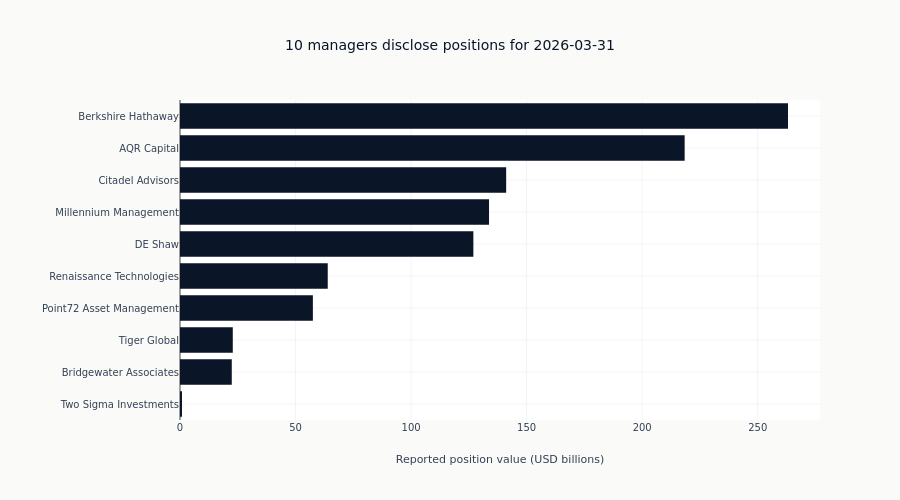

In [19]:
if len(latest_holdings) > 0:
    # Plot 1: Holdings distribution by institution
    inst_stats = (
        latest_holdings.group_by(["cik", "company_name"])
        .agg(
            [
                pl.col("cusip").n_unique().alias("n_holdings"),
                (pl.col("reported_value_usd").sum() / 1e9).alias("total_value_usd_bn"),
            ]
        )
        .with_columns(pl.col("cik").replace(INSTITUTION_NAMES).alias("institution_name"))
        .sort("total_value_usd_bn")
    )

    fig1 = go.Figure(
        go.Bar(
            x=inst_stats["total_value_usd_bn"],
            y=inst_stats["institution_name"],
            orientation="h",
            marker_color=COLORS["blue"],
            customdata=inst_stats["n_holdings"],
            hovertemplate="%{y}<br>Value: $%{x:.1f}B<br>Positions: %{customdata}<extra></extra>",
        )
    )
    fig1.update_layout(
        title=f"{latest_holdings['cik'].n_unique()} managers disclose positions for {latest_period}",
        xaxis_title="Reported position value (USD billions)",
        yaxis_title=None,
        height=500,
        width=900,
        showlegend=False,
        margin=dict(l=180),
    )
    fig1.show()

**Interpretation**: The bar chart separates breadth from scale. Institutions
with fewer holdings but similar total value are expressing higher conviction
than diversified peers with comparable assets under management.

In [20]:
if len(latest_holdings) > 0:
    # Plot 2: Top holdings across all institutions
    top_stocks = (
        latest_holdings.group_by("cusip")
        .agg(
            [
                pl.col("issuer").first().alias("issuer"),
                pl.col("cik").n_unique().alias("n_institutions"),
                (pl.col("reported_value_usd").sum() / 1e9).alias("total_value_usd_bn"),
            ]
        )
        .sort(
            ["n_institutions", "total_value_usd_bn", "cusip"],
            descending=[True, True, False],
        )
        .head(20)
        .with_columns(
            (pl.col("issuer") + pl.lit(" [") + pl.col("cusip").str.slice(-4) + pl.lit("]")).alias(
                "display_label"
            )
        )
    )

Use a horizontal bar chart for the deterministic breadth-first selection.
The CUSIP suffix makes every categorical label unique.

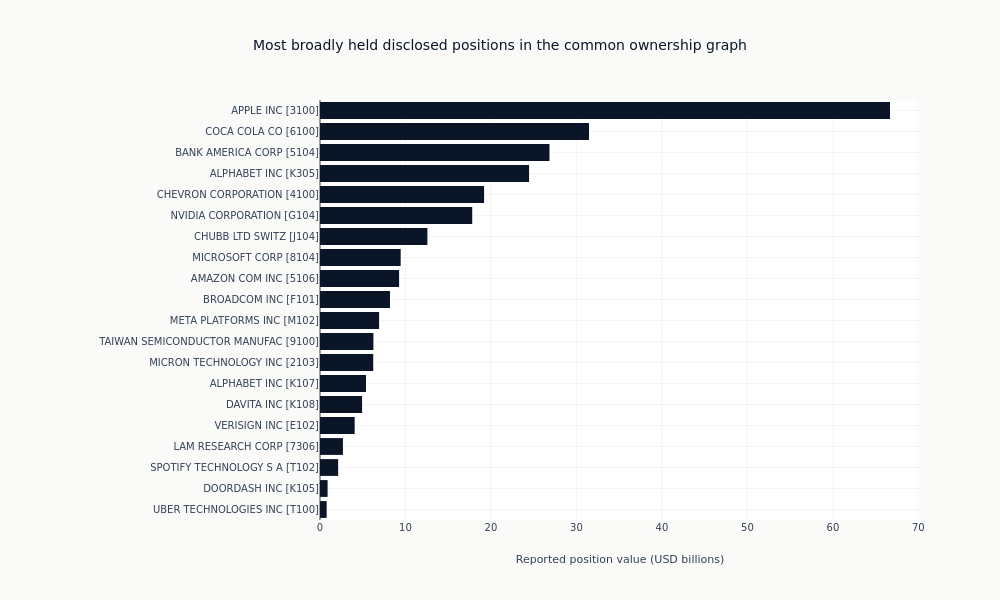

In [21]:
if len(latest_holdings) > 0:
    top_stocks_pd = top_stocks.sort("total_value_usd_bn", descending=False).to_pandas()
    fig2 = go.Figure(
        go.Bar(
            x=top_stocks_pd["total_value_usd_bn"],
            y=top_stocks_pd["display_label"],
            orientation="h",
            marker_color=COLORS["blue"],
            customdata=top_stocks_pd["n_institutions"],
            hovertemplate="%{y}<br>Value: $%{x:.1f}B<br>Managers: %{customdata}<extra></extra>",
        )
    )
    fig2.update_layout(
        title="Most broadly held disclosed positions in the common ownership graph",
        xaxis_title="Reported position value (USD billions)",
        yaxis_title=None,
        height=600,
        width=1000,
        margin=dict(l=320),
    )
    fig2.show()

**Interpretation**: Widely held stocks are not automatically attractive
signals. Ownership breadth is a graph descriptor, not evidence of future returns.

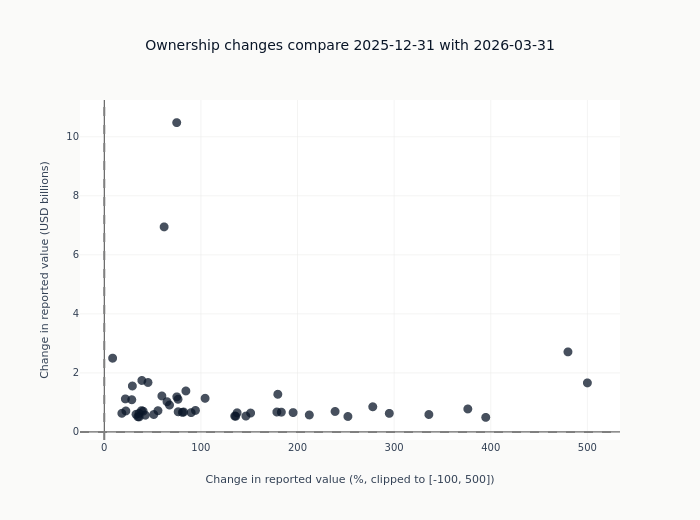

In [22]:
if qoq is not None and len(qoq) > 0:
    # Plot 3: Institutional ownership-change scatter
    momentum_plot = qoq.filter(pl.col("n_institutions") >= 2).sort(
        "value_change_usd", descending=True
    )

    if len(momentum_plot) > 0:
        mom_pd = momentum_plot.filter(pl.col("pct_change").is_not_null()).head(50).to_pandas()
        mom_pd["pct_change_pct"] = (100 * mom_pd["pct_change"]).clip(lower=-100, upper=500)
        mom_pd["value_change_usd_bn"] = mom_pd["value_change_usd"] / 1e9
        fig3 = go.Figure(
            go.Scatter(
                x=mom_pd["pct_change_pct"],
                y=mom_pd["value_change_usd_bn"],
                mode="markers",
                marker=dict(color=COLORS["blue"], size=9, opacity=0.75),
                text=mom_pd["issuer_name"],
                hovertemplate=(
                    "%{text}<br>Change: %{x:.1f}%<br>Value change: $%{y:.2f}B<extra></extra>"
                ),
            )
        )
        fig3.update_layout(
            title=f"Ownership changes compare {prior_period} with {current_period}",
            xaxis_title="Change in reported value (%, clipped to [-100, 500])",
            yaxis_title="Change in reported value (USD billions)",
            height=520,
            showlegend=False,
        )
        fig3.add_hline(y=0, line_dash="dash", line_color="gray")
        fig3.add_vline(x=0, line_dash="dash", line_color="gray")
        fig3.show()

**Interpretation**: The upper-right quadrant highlights names where both the
dollar value and percentage ownership are rising. Those are the strongest
candidates for a delayed ownership-change feature.

## Part 8: Feature Engineering for ML Models

Create point-in-time features that can be joined to price data for validation.

In [23]:
if len(latest_holdings) > 0:
    # Stock-level features for ML
    stock_features = (
        latest_holdings.group_by("cusip")
        .agg(
            [
                pl.col("issuer").first().alias("issuer_name"),
                # Ownership breadth
                pl.col("cik").n_unique().alias("n_inst_holders"),
                # Value concentration
                pl.col("reported_value_usd").sum().alias("total_inst_value_usd"),
                pl.col("reported_value_usd").mean().alias("avg_position_size_usd"),
                pl.col("reported_value_usd").std().fill_null(0).alias("position_size_std_usd"),
                pl.col("timestamp").max().alias("timestamp"),
                # Ownership concentration (HHI)
                (pl.col("reported_value_usd") / pl.col("reported_value_usd").sum())
                .pow(2)
                .sum()
                .alias("ownership_hhi"),
            ]
        )
        .with_columns(
            [
                # Derived features
                (pl.col("n_inst_holders") / len(INSTITUTIONS)).alias("inst_coverage_pct"),
                (
                    pl.col("position_size_std_usd")
                    / pl.col("avg_position_size_usd").clip(lower_bound=1)
                ).alias("position_cv"),
            ]
        )
        .sort("cusip")
    )

    print("=== Stock-Level Features for ML ===")
    print(f"Features generated for {len(stock_features)} stocks")
    print("\nFeature summary:")
    print(stock_features.describe())

=== Stock-Level Features for ML ===
Features generated for 7998 stocks

Feature summary:
shape: (9, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ cusip     ┆ issuer_na ┆ n_inst_ho ┆ … ┆ timestamp ┆ ownership ┆ inst_cove ┆ position │
│ ---       ┆ ---       ┆ me        ┆ lders     ┆   ┆ ---       ┆ _hhi      ┆ rage_pct  ┆ _cv      │
│ str       ┆ str       ┆ ---       ┆ ---       ┆   ┆ str       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆ str       ┆ f64       ┆   ┆           ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 7998      ┆ 7998      ┆ 7998.0    ┆ … ┆ 7998      ┆ 7998.0    ┆ 7998.0    ┆ 7998.0   │
│ null_coun ┆ 0         ┆ 0         ┆ 0.0       ┆ … ┆ 0         ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           

**Interpretation**: The feature summary describes quarter-end ownership
snapshots. It does not establish how long any feature remains informative.


In [24]:
if len(latest_holdings) > 0:
    # Add momentum features if available
    if qoq is not None and len(qoq) > 0:
        momentum_features = qoq.select(
            [
                "cusip",
                pl.col("value_change_usd").alias("inst_value_change_usd"),
                pl.col("pct_change").alias("inst_pct_change"),
            ]
        )
        stock_features = (
            stock_features.join(momentum_features, on="cusip", how="left")
            .with_columns(pl.col("inst_value_change_usd").fill_null(0))
            .sort("cusip")
        )
        print("Added momentum features")

    display(stock_features.head(10))

Added momentum features


cusip,issuer_name,n_inst_holders,total_inst_value_usd,avg_position_size_usd,position_size_std_usd,timestamp,ownership_hhi,inst_coverage_pct,position_cv,inst_value_change_usd,inst_pct_change
str,str,u32,f64,f64,f64,date,f64,f64,f64,f64,f64
"""00032Q104""","""WHITEHAWK THERAPEUTICS INC""",4,2.9607e6,740175.0,644579.021549,2026-05-15,0.392195,0.4,0.870847,1.654694e6,1.266988
"""000360206""","""AAON INC""",4,3.4879623e7,8.7199e6,1.4905e7,2026-05-15,0.797826,0.4,1.709309,-6.73903e6,-0.161923
"""000361105""","""AAR CORP""",5,1.1035429e7,2207085.8,1.8525e6,2026-05-15,0.312714,0.5,0.839322,-7.988389e6,-0.419915
"""00039J301""","""AB ACTIVE ETFS INC""",1,551959.0,551959.0,0.0,2026-05-15,1.0,0.1,0.0,129364.0,0.306118
"""00039J509""","""AB ACTIVE ETFS INC""",1,241763.0,241763.0,0.0,2026-05-15,1.0,0.1,0.0,9242.0,0.039747
"""00039J707""","""AB ACTIVE ETFS INC""",1,664955.0,664955.0,0.0,2026-05-15,1.0,0.1,0.0,664955.0,null
"""00039J764""","""AB ACTIVE ETFS INC""",1,251945.0,251945.0,0.0,2026-05-15,1.0,0.1,0.0,251945.0,null
"""00039J772""","""AB ACTIVE ETFS INC""",1,253526.0,253526.0,0.0,2026-05-15,1.0,0.1,0.0,253526.0,null
"""00039J822""","""AB ACTIVE ETFS INC""",2,1.150455e6,575227.5,149498.636999,2026-05-15,0.516886,0.2,0.259895,425445.0,0.586813


### Canonical artifact parity

Confirm that the downloader's latest-quarter edge and feature artifacts are
the same objects constructed above, rather than stale snapshots.

In [25]:
if len(latest_holdings) > 0:
    expected_edges = latest_holdings.select(
        pl.col("cik").alias("institution_id"),
        pl.col("cusip").alias("stock_id"),
        pl.col("company_name").alias("institution_name"),
        pl.col("issuer").alias("stock_name"),
        pl.col("reported_value_usd").alias("weight_value"),
        pl.col("shares").alias("weight_shares"),
        pl.col("report_period").alias("report_date"),
        "timestamp",
    )
    canonical_edges = load_13f_edges()
    canonical_features = load_13f_stock_features()
    assert_frame_equal(
        expected_edges.sort(["institution_id", "stock_id"]),
        canonical_edges.sort(["institution_id", "stock_id"]),
        check_row_order=True,
    )
    assert_frame_equal(
        stock_features.sort("cusip"),
        canonical_features.sort("cusip"),
        check_row_order=True,
        rel_tol=1e-6,
    )
    print("Canonical edge and stock-feature artifact parity: PASS")

Canonical edge and stock-feature artifact parity: PASS


**Interpretation**: The feature table is the real bridge to modeling.
Breadth, concentration, and ownership-change variables can be merged with
price data as point-in-time cross-sectional features in Chapter 23 pipelines.
The canonical producer (`data/equities/positioning/13f_download.py`) writes
the same features to `$ML4T_DATA_PATH/equities/positioning/13f/`, and
downstream notebooks consume them via `load_13f_stock_features()`.

## Part 9: Artifacts on Disk

The canonical downloader writes all graph artifacts (holdings, edge list,
stock features, co-ownership matrix, stock list) to
`$ML4T_DATA_PATH/equities/positioning/13f/`. Chapter 23 notebooks read
those files directly via `load_13f_edges()` and `load_13f_stock_features()`.
This notebook is a consumer of the holdings artifact, not a producer - its
derived tables (above) are for inspection and pedagogy only.

In [26]:
print("=== Canonical 13F Artifacts ===")
print("Writer:    data/equities/positioning/13f_download.py")
print("Location:  $ML4T_DATA_PATH/equities/positioning/13f/")
print("Files:     institutional_holdings.parquet")
print("           institution_stock_edges.parquet")
print("           stock_features.parquet")
print("           coownership_matrix.npy")
print("           coownership_stocks.txt")
print("Loaders:   load_institutional_holdings_13f(), load_13f_edges(),")
print("           load_13f_stock_features()")

=== Canonical 13F Artifacts ===
Writer:    data/equities/positioning/13f_download.py
Location:  $ML4T_DATA_PATH/equities/positioning/13f/
Files:     institutional_holdings.parquet
           institution_stock_edges.parquet
           stock_features.parquet
           coownership_matrix.npy
           coownership_stocks.txt
Loaders:   load_institutional_holdings_13f(), load_13f_edges(),
           load_13f_stock_features()


## Results Interpretation

**Co-ownership structure**: The bipartite institution-stock graph is highly
sparse - most stock pairs share zero institutional holders. High-similarity
pairs identify common disclosed owners; return comovement is not tested here.

**Institutional ownership change**: Quarter-over-quarter changes describe how
aggregate reported holdings moved. The filing-date availability timestamp
records when each complete included-manager snapshot became observable. This
notebook does not estimate persistence or forward-return predictiveness.

**Crowding risk**: Stocks held by many funds with similar portfolio weights
receive a high descriptive crowding score (breadth / HHI). The notebook does
not observe liquidation or price impact.

## Summary: What We Can Do With 13F Data

### Implemented Features

| Feature | Description | Use Case |
|---------|-------------|----------|
| `n_inst_holders` | Number of institutions holding stock | Crowding risk |
| `total_inst_value_usd` | Total reported position value (USD) | Ownership scale |
| `ownership_hhi` | Concentration of ownership | Crowding risk |
| `inst_value_change_usd` | Quarter-over-quarter value change | Ownership change |
| `inst_pct_change` | Fractional change in reported value | Ownership change |
| Co-ownership matrix | Stock-stock similarity | Clustering, GNN |

In [27]:
print("\n=== Analysis Summary ===")
if len(positions_df) > 0:
    print(f"Institutions: {positions_df['cik'].n_unique()}")
    print(f"Unique stocks: {positions_df['cusip'].n_unique()}")
    print(f"Aggregated positions: {len(positions_df):,}")
    try:
        print(f"Stock features (derived): {len(stock_features)}")
    except NameError:
        print("Stock features (derived): 0")


=== Analysis Summary ===
Institutions: 10
Unique stocks: 10273
Aggregated positions: 95,845
Stock features (derived): 7998


## Key Takeaways

**Interpretation**: The closing pipeline summary shows why 13F data remains
useful despite reporting lag. The result is a quarter-end ownership lens that
complements returns, risk, and graph modeling workflows.

1. SEC 13F filings provide a structured, machine-readable view of institutional
   equity ownership. The canonical downloader at
   `data/equities/positioning/13f_download.py` walks EDGAR and writes a
   normalized holdings artifact consumed here via `load_institutional_holdings_13f()`.
2. Co-ownership cosine similarity creates a stock-stock graph where edges
   represent shared institutional holders - useful for clustering, GNN message
   passing, and diversification analysis.
3. Quarter-over-quarter ownership change and concentration are descriptive
   candidates whose predictive value requires a point-in-time return study.
4. The 45-day filing deadline limits real-time use; `timestamp` records when
   the complete included-manager snapshot becomes available.

**Chapter Connections**:
- **Chapter 23 (Knowledge Graphs)**: Use the bipartite graph for GNN message passing
- **Chapter 11 (ML Pipeline)**: Join features to price data for cross-sectional models
- **Chapter 12 (Gradient Boosting)**: Use crowding and ownership change as tree model features
- **Chapter 24 (Autonomous Agents)**: Natural language queries about institutional holdings

**Limitations**:
- Only long equity positions (no shorts, no derivatives)
- >$100M AUM threshold misses smaller funds
- Confidential treatment exemptions hide some positions

**Next**: Chapter 23 converts these ownership links into structured graph
representations, while Chapter 24 uses the same entities in agentic workflows.